# Detección de Código Generado por IA — SemEval-2026 Task 13 (Subtask A)

**Equipo (EquipoCompiladores):** Juan Pablo Chávez Leal · Mauricio Anguiano Juárez · Daniel Contreras Chávez — ITESM, Campus Querétaro (TC3002B).

Clasificación de fragmentos de código: humano (0) vs generado por IA (1), replicando a Ramachandra et al. (2026).

In [ ]:
# ============================================================
# Instalacion e imports
# ============================================================
%pip install -q kagglehub xgboost scikit-learn pandas numpy pyarrow matplotlib
%pip install -q transformers torch safetensors

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports listos.')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Mauricio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Mauricio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Imports listos.


In [ ]:
# ============================================================
# Descarga del dataset SemEval-2026 Task 13
# ============================================================
import kagglehub

DATASET_PATH = kagglehub.dataset_download('daniilor/semeval-2026-task13')
print('Dataset descargado en:', DATASET_PATH)

Dataset descargado en: C:\Users\Mauricio\.cache\kagglehub\datasets\daniilor\semeval-2026-task13\versions\3


In [ ]:
# ============================================================
# Carga del dataset SemEval (Subtask A = carpeta task_a)
# ============================================================
all_parquets = glob.glob(os.path.join(DATASET_PATH, '**', '*.parquet'), recursive=True)
train_file = [p for p in all_parquets if 'task_a_training' in p.lower()][0]
val_file = [p for p in all_parquets if 'task_a_validation' in p.lower()][0]
print('Train:', train_file)
print('Val:  ', val_file)

def carga_split(path):
    d = pd.read_parquet(path)
    d = d.dropna(subset=['code', 'label']).reset_index(drop=True)
    d['label'] = d['label'].astype(int)
    return d

df_tr = carga_split(train_file)
df_val = carga_split(val_file)

codes_tr = df_tr['code'].astype(str).tolist()
y_tr = df_tr['label'].values
codes_val = df_val['code'].astype(str).tolist()
y_val = df_val['label'].values

print(f'\nTrain: {len(y_tr)} filas | 0 (humano): {(y_tr==0).sum()} | 1 (maquina): {(y_tr==1).sum()}')
print(f'Val:   {len(y_val)} filas | 0 (humano): {(y_val==0).sum()} | 1 (maquina): {(y_val==1).sum()}')
df_tr.head(3)

Train: C:\Users\Mauricio\.cache\kagglehub\datasets\daniilor\semeval-2026-task13\versions\3\SemEval-2026-Task13\task_a\task_a_training_set_1.parquet
Val:   C:\Users\Mauricio\.cache\kagglehub\datasets\daniilor\semeval-2026-task13\versions\3\SemEval-2026-Task13\task_a\task_a_validation_set.parquet

Train: 500000 filas | 0 (humano): 238475 | 1 (maquina): 261525
Val:   100000 filas | 0 (humano): 47695 | 1 (maquina): 52305


,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python


## Enfoque principal — Features + TF-IDF + Random Forest / XGBoost

(La explicación completa de la metodología está en `README_retov3.md`.)

In [ ]:
# ============================================================
# Features del codigo + TF-IDF
# ============================================================
def code_features(src):
    lines = src.split('\n')
    n_lines = len(lines)
    n_chars = len(src)
    n_blank = sum(1 for ln in lines if ln.strip() == '')
    n_comment = sum(1 for ln in lines if ln.strip().startswith(('#', '//', '/*', '*')))
    indents = [len(ln) - len(ln.lstrip(' ')) for ln in lines if ln.strip()]
    avg_indent = (sum(indents) / len(indents)) if indents else 0.0
    avg_line_len = (sum(len(ln) for ln in lines) / n_lines) if n_lines else 0.0
    n_space = src.count(' ')
    n_tab = src.count('\t')
    ratio_ws = ((n_space + n_tab) / n_chars) if n_chars else 0.0
    ratio_comment = (n_comment / n_lines) if n_lines else 0.0
    ratio_blank = (n_blank / n_lines) if n_lines else 0.0
    return [n_lines, n_chars, n_blank, n_comment, avg_indent, avg_line_len, n_space, n_tab, ratio_ws, ratio_comment, ratio_blank]

FEATURE_NAMES = ['n_lines','n_chars','n_blank','n_comment','avg_indent','avg_line_len','n_space','n_tab','ratio_ws','ratio_comment','ratio_blank']

X_feat_tr = np.array([code_features(c) for c in codes_tr], dtype='float32')
X_feat_val = np.array([code_features(c) for c in codes_val], dtype='float32')
print('Features train:', X_feat_tr.shape, '| val:', X_feat_val.shape)

# TF-IDF sobre tokens del codigo.
tfidf = TfidfVectorizer(lowercase=False, token_pattern=r'[A-Za-z_][A-Za-z0-9_]*|[^\sA-Za-z0-9_]', ngram_range=(1, 2), max_features=20000, min_df=2)
X_tfidf_tr = tfidf.fit_transform(codes_tr)
X_tfidf_val = tfidf.transform(codes_val)
print('TF-IDF train:', X_tfidf_tr.shape, '| val:', X_tfidf_val.shape)

# Concatena features tabulares + TF-IDF en una matriz sparse
scaler = StandardScaler()
X_tr = hstack([csr_matrix(scaler.fit_transform(X_feat_tr)), X_tfidf_tr]).tocsr()
X_val = hstack([csr_matrix(scaler.transform(X_feat_val)), X_tfidf_val]).tocsr()
print('Matriz combinada train:', X_tr.shape, '| val:', X_val.shape)

Features train: (500000, 11) | val: (100000, 11)
TF-IDF train: (500000, 20000) | val: (100000, 20000)
Matriz combinada train: (500000, 20011) | val: (100000, 20011)


In [ ]:
# ============================================================
# Entrenamiento Random Forest y XGBoost (Sugerida por Ramachandra et al)
# ============================================================
results = {}

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, n_jobs=-1,
    class_weight='balanced', random_state=RANDOM_STATE)
rf.fit(X_tr, y_tr)
rf_pred = rf.predict(X_val)
rf_f1 = f1_score(y_val, rf_pred, average='macro')
results['RandomForest'] = rf_f1
print(f'Random Forest  -> macro F1 = {rf_f1:.4f}')
print(classification_report(y_val, rf_pred, digits=4))

# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE)
xgb.fit(X_tr, y_tr)
xgb_pred = xgb.predict(X_val)
xgb_f1 = f1_score(y_val, xgb_pred, average='macro')
results['XGBoost'] = xgb_f1
print(f'\nXGBoost  -> macro F1 = {xgb_f1:.4f}')
print(classification_report(y_val, xgb_pred, digits=4))

Random Forest  -> macro F1 = 0.9832
              precision    recall  f1-score   support

           0     0.9867    0.9780    0.9823     47695
           1     0.9801    0.9880    0.9840     52305

    accuracy                         0.9832    100000
   macro avg     0.9834    0.9830    0.9832    100000
weighted avg     0.9832    0.9832    0.9832    100000


XGBoost  -> macro F1 = 0.9917
              precision    recall  f1-score   support

           0     0.9906    0.9921    0.9914     47695
           1     0.9928    0.9914    0.9921     52305

    accuracy                         0.9918    100000
   macro avg     0.9917    0.9918    0.9917    100000
weighted avg     0.9918    0.9918    0.9918    100000



In [ ]:
# ============================================================
# Desglose de resultados por lenguaje y generador
# ============================================================
# Utilizamos las columnas extra del dataset para ver donde le atina
# y cuando falla XGBoost en validacion.
df_val['pred_xgb'] = xgb_pred
df_val['correcto'] = (df_val['label'] == df_val['pred_xgb'])

print('Macro F1 de XGBoost:')
for lang, sub in df_val.groupby('language'):
    print(f"  {str(lang):12s} {f1_score(sub['label'], sub['pred_xgb'], average='macro'):.4f}  (n={len(sub)})")

print('\nCorrectas por generador:')
correctas = df_val.groupby('generator')['correcto'].mean()
conteo = df_val.groupby('generator')['correcto'].size()
for gen in correctas.sort_values().index:
    print(f'  {str(gen):25s} {correctas[gen]:.4f}  (n={conteo[gen]})')

Macro F1 por lenguaje (XGBoost):
  C++          0.9617  (n=4679)
  Java         0.9629  (n=3860)
  Python       0.9945  (n=91461)

Acierto por generador (fraccion bien clasificada):
  ibm-granite/granite-8b-code-base-4k 0.9633  (n=1362)
  codellama/CodeLlama-34b-Instruct-hf 0.9702  (n=1544)
  ibm-granite/granite-8b-code-instruct-4k 0.9799  (n=846)
  deepseek-ai/deepseek-coder-6.7b-base 0.9818  (n=1207)
  meta-llama/Llama-3.3-70B-Instruct 0.9829  (n=1756)
  bigcode/starcoder         0.9833  (n=1857)
  meta-llama/Llama-3.1-8B   0.9837  (n=1351)
  microsoft/phi-2           0.9842  (n=1966)
  Qwen/Qwen2.5-Coder-7B     0.9846  (n=1427)
  bigcode/starcoder2-15b    0.9882  (n=1872)
  codellama/CodeLlama-7b-hf 0.9885  (n=1128)
  google/codegemma-2b       0.9892  (n=1484)
  google/codegemma-7b       0.9897  (n=1258)
  bigcode/starcoder2-7b     0.9904  (n=1350)
  meta-llama/Llama-3.2-1B   0.9921  (n=760)
  human                     0.9921  (n=47695)
  meta-llama/Llama-3.2-3B   0.9923  (n=1550)
 

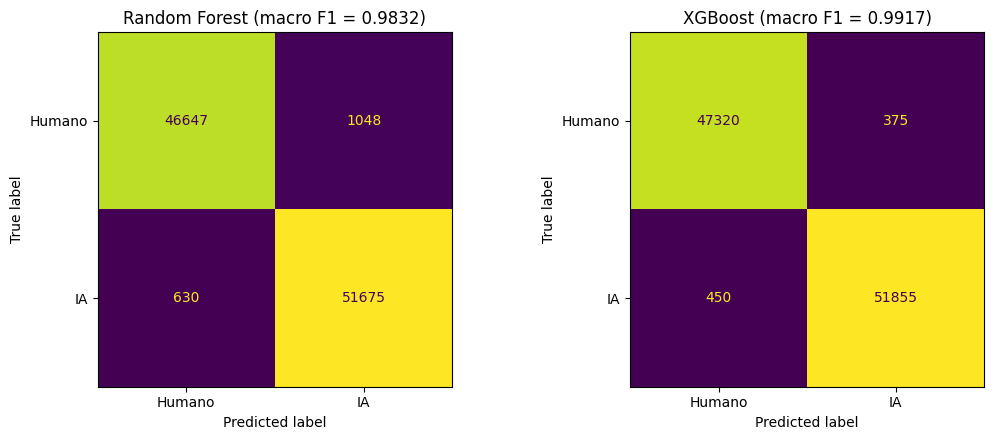

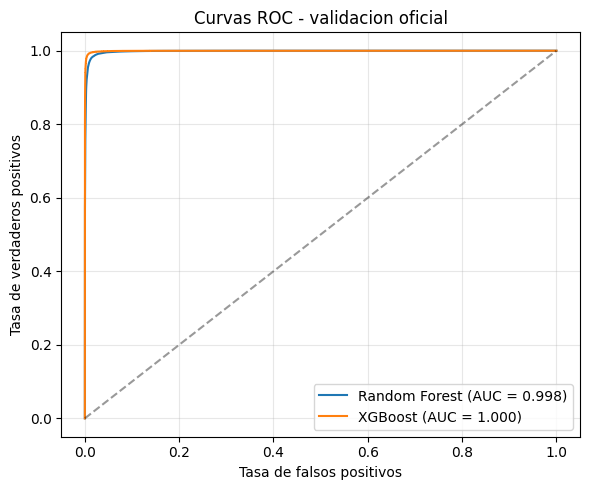

Figuras guardadas en figuras/


In [ ]:
# ============================================================
# Matrices de confusion y curvas ROC (RF y XGBoost)
# ============================================================
os.makedirs('figuras', exist_ok=True)

# Matrices de confusion de validacion
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nombre, pred, clave) in zip(axes, [('Random Forest', rf_pred, 'RandomForest'),
                                            ('XGBoost', xgb_pred, 'XGBoost')]):
    cm = confusion_matrix(y_val, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Humano', 'IA']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{nombre} (macro F1 = {results[clave]:.4f})')
plt.tight_layout()
plt.savefig('figuras/matrices_confusion.png', dpi=130, bbox_inches='tight')
plt.show()

# Curvas ROC
fig, ax = plt.subplots(figsize=(6, 5))
for nombre, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    probs = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, probs)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC = {auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC - validacion oficial')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/curvas_roc.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figuras guardadas en figuras/')

In [4]:
# ============================================================
# Importancia de features de XGBoost
# ============================================================
# Las primeras 11 columnas de la matriz son las features estructurales
# y el resto son los n-gramas del TF-IDF, con esto vemos en que se
# fija el modelo para decidir humano vs IA.
nombres = FEATURE_NAMES + list(tfidf.get_feature_names_out())
importancias = xgb.feature_importances_
top = np.argsort(importancias)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['darkorange' if i < len(FEATURE_NAMES) else 'steelblue' for i in top]
ax.bar(range(len(top)), importancias[top], color=colores, alpha=0.85)
ax.set_xticks(range(len(top)))
ax.set_xticklabels([repr(nombres[i]) for i in top], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Importancia')
ax.set_title('Features de XGBoost (naranja = estructural, azul = n-grama TF-IDF)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Features mas importantes:')
for i in top[:10]:
    tipo = 'estructural' if i < len(FEATURE_NAMES) else 'tf-idf'
    print(f'  {nombres[i]!r:35s} {importancias[i]:.4f}  ({tipo})')

NameError: name 'FEATURE_NAMES' is not defined

## Persistencia — guardar y recargar los modelos entrenados

**Primera vez:** corre todo el notebook y ejecuta la celda GUARDAR (12).
**Kernel nuevo (sin reentrenar):** corre la CELDA 1 y luego la celda CARGAR (13); con eso puedes saltarte las celdas 2 a 11.

(El flujo completo está documentado en `README_retov3.md`.)

In [ ]:
# ============================================================
# Guardado de modelos
# ============================================================
import joblib

ARTIFACTS_DIR = 'artefactos_reto'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

joblib.dump(
    {'rf': rf, 'xgb': xgb,
     'tfidf': tfidf, 'scaler': scaler, 'results': results},
    os.path.join(ARTIFACTS_DIR, 'modelos_entrenados.joblib'),
    compress=3)

print('Artefactos guardados en:', os.path.abspath(ARTIFACTS_DIR))
for f in sorted(os.listdir(ARTIFACTS_DIR)):
    ruta = os.path.join(ARTIFACTS_DIR, f)
    print(f'  {f:30s} {os.path.getsize(ruta)/1e6:8.2f} MB')

Artefactos guardados en: c:\Users\Mauricio\Documents\Escuela\PlagioCompiladores\Reto-Compiladores-Plagio-\artefactos_reto
  X_cb.npy                          15.36 MB
  X_cb_tr.npy                       15.36 MB
  X_cb_val.npy                       3.07 MB
  modelos_entrenados.joblib        380.50 MB
  y_cb.npy                           0.04 MB
  y_cb_tr.npy                        0.04 MB
  y_cb_val.npy                       0.01 MB


In [5]:
# ============================================================
# Carga de modelo
# ============================================================
import joblib

ARTIFACTS_DIR = 'artefactos_reto'
ARTIFACTS_PATH = os.path.join(ARTIFACTS_DIR, 'modelos_entrenados.joblib')
print(ARTIFACTS_PATH)

bundle  = joblib.load(ARTIFACTS_PATH)
rf      = bundle['rf']
xgb     = bundle['xgb']
tfidf   = bundle['tfidf']
scaler  = bundle['scaler']
results = bundle['results']

def code_features(src):
    lines = src.split('\n')
    n_lines = len(lines)
    n_chars = len(src)
    n_blank = sum(1 for ln in lines if ln.strip() == '')
    n_comment = sum(1 for ln in lines if ln.strip().startswith(('#', '//', '/*', '*')))
    indents = [len(ln) - len(ln.lstrip(' ')) for ln in lines if ln.strip()]
    avg_indent = (sum(indents) / len(indents)) if indents else 0.0
    avg_line_len = (sum(len(ln) for ln in lines) / n_lines) if n_lines else 0.0
    n_space = src.count(' ')
    n_tab = src.count('\t')
    ratio_ws = ((n_space + n_tab) / n_chars) if n_chars else 0.0
    ratio_comment = (n_comment / n_lines) if n_lines else 0.0
    ratio_blank = (n_blank / n_lines) if n_lines else 0.0
    return [n_lines, n_chars, n_blank, n_comment, avg_indent, avg_line_len, n_space, n_tab, ratio_ws, ratio_comment, ratio_blank]

print('Modelos cargados:')
for k, v in results.items():
    print(f'  {k:30s} macro F1 = {v:.4f}')

NameError: name 'os' is not defined

## Evaluación

Resultados de SemEval Subtask A, con la métrica macro F1.

In [6]:
# ============================================================
# Tabla comparativa de modelos con macro F1
# ============================================================
tabla = pd.DataFrame(
    [(k, v) for k, v in results.items()],
    columns=['Modelo', 'macro_F1']
).sort_values('macro_F1', ascending=False).reset_index(drop=True)
print('Comparativa de modelos')
print(tabla.to_string(index=False))

tabla

NameError: name 'pd' is not defined

# Resumen
Dataset utilizado: SemEval-2026 Task 13 <br>
Métrica utilizada: F1 <br>
Modelos: <br>
XGBoost: F1 de 0.99 <br>
RandomForest: F1 de 0.98 <br>



# Uso

In [ ]:
# ============================================================
# Prediccion sobre un fragmento de codigo
# ============================================================

def predict_code(src, model=rf):
    feats = scaler.transform(np.array([code_features(src)], dtype='float32'))
    tf = tfidf.transform([src])
    x = hstack([csr_matrix(feats), tf]).tocsr()
    pred = int(model.predict(x)[0])
    etiqueta = 'Generado por IA)' if pred == 1 else 'HUMANO'
    return pred, etiqueta

# Ejemplo de prueba
ejemplo = '''def suma(a, b):
    # suma dos numeros
    return a + b
'''
pred, etiqueta = predict_code(ejemplo)
print('Prediccion:', pred, '->', etiqueta)

Prediccion: 1 -> MAQUINA (generado por IA)
